# Patrón 10: CodeAct Agent

### ¿Qué es?

CodeAct es un enfoque alternativo al tool calling tradicional. En lugar de generar JSON estructurado para describir una llamada de herramienta, el LLM escribe **código ejecutable** que llama directamente las funciones o APIs necesarias.

Esta arquitectura es usada por **Manus.im** e implementa una alternativa al JSON function-calling que permite resolver tareas más complejas en menos pasos. Esto se logra usando el poder completo de un lenguaje de programación Turing-completo (Python) para combinar y transformar las salidas de múltiples herramientas.

### CodeAct vs Tool Calling (JSON)

| Dimensión | Tool Calling (JSON) | CodeAct (Python) |
|---|---|---|
| **Formato de acción** | `{"tool": "search", "args": {...}}` | `result = search(query); process(result)` |
| **Flexibilidad** | Solo tools predefinidas | Cualquier lógica Python |
| **Multi-step** | 1 tool por turno → N turnos | N operaciones en 1 bloque de código |
| **Token efficiency** | Alta latencia acumulada | ~30% menos tokens |
| **Self-correction** | No nativo | Error → rewrite loop nativo |
| **Sandbox** | No necesario | E2B / Docker / eval() |
| **Estado entre turnos** | Solo via State | Variables Python persisten entre turnos |

Ventaja clave
El paper de CodeAct demostró que los agentes pueden encadenar muchas acciones escribiendo y ejecutando código. Anthropic destacó el beneficio en ahorro de tokens porque el agente no procesa los resultados intermedios de las herramientas.


Caso de uso: Análisis Inteligente de GitHub Issues

Dataset: davidshinn/github-issues
URL: https://www.kaggle.com/datasets/davidshinn/github-issues

Descripción: ~100k issues reales de GitHub con campos: url, repository_url, title, body, user, state, labels, comments, created_at, closed_at

Tamaño: ~50 MB CSV | Licencia: CC0 Public Domain

¿Por qué es ideal para CodeAct?

El agente necesita combinar NLP, pandas, regex, visualizaciones y lógica de clasificación en bloques Python dinámicos — imposible con tool-calling JSON estándar en menos de 10 turnos.


Dependencias:
```bash
!pip install -q langgraph-codeact langchain-anthropic langchain-core langgraph
!pip install -q kagglehub matplotlib seaborn wordcloud scikit-learn
```

Diagrama:
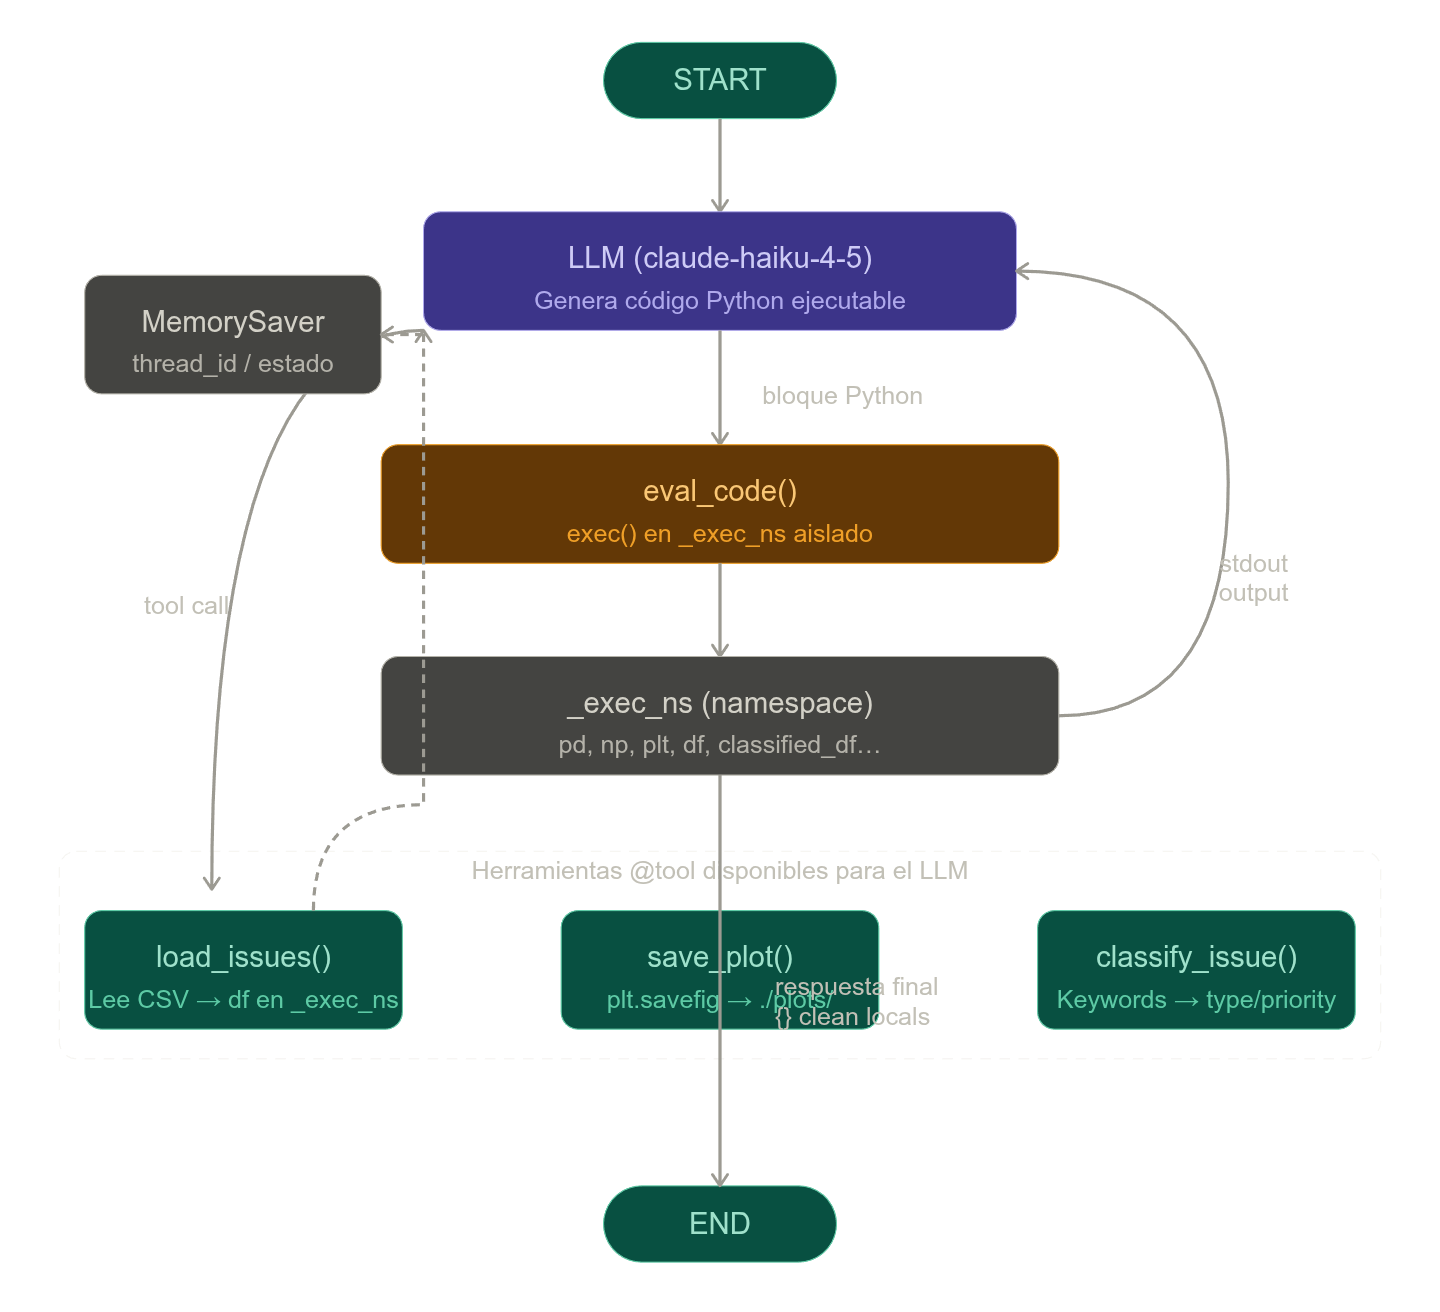

Componentes:

|Nodo/Componente|Tipo|Función|Descripción|
|:--------------|:---|:------|:----------|
|LLM claude-haiku-4-5|Modelo|Generar Código|Recibe el prompt del usuario y genera bloques de código Python ejecutables. Razona qué operaciones hacer (pandas, sklearn, matplotlib) sin tools predefinidas para cada una|
|eval_code()|Sandbox|Ejecutar Código|Función central de CodeAct. Recibe el bloque Python del LLM, lo ejecuta con exec() dentro de _exec_ns y captura el stdout. Devuelve siempre {} como clean_locals para evitar el error msgpack de LangGraph.|
|_exec_ns|Namespace|Persistir variables|Diccionario Python que actúa como namespace compartido entre turnos del agente. Contiene módulos (pd, np, plt) y variables generadas (df, classified_df, duplicate_pairs). Nunca lo ve LangGraph — evita errores de serialización.|
|load_issues()|Tool|Cargar dataset|Lee el CSV de GitHub Issues con pd.read_csv() e inyecta el DataFrame df directamente en _exec_ns. El LLM la llama al inicio de cada tarea.|
|save_plot()|Tool|Guardar gráfico|Ejecuta plt.savefig() y plt.close() en el scope real del notebook (no dentro de exec()), garantizando que el archivo PNG se escribe en ./plots/ correctamente.|
|classify_issue()|Tool|Clasificar Issue|Clasifica un issue en bug / feature / question / performance / security usando keywords deterministas. Permite al LLM validar su clasificación vectorizada contra reglas fijas.|
|MemorySaver|Checkpointer|Persistir estado|Checkpointer in-memory de LangGraph. Guarda el estado del grafo por thread_id, permitiendo continuar conversaciones entre celdas del notebook. Solo serializa mensajes y primitivos — nunca toca _exec_ns.|
|config thread_id+recursion_limit|Config|Controlar ejecución|thread_id aísla cada tarea en su propia sesión. recursion_limit: 50 aumenta el máximo de pasos del grafo (default 25) para tasks complejas que requieren múltiples iteraciones de código → ejecución → corrección.|


### Cuándo usar CodeAct
- ✅ Tasks que requieren **combinar múltiples herramientas** en un solo flujo
- ✅ Análisis de datos con transformaciones complejas (pandas, numpy)
- ✅ Automatización de tareas de ingeniería (scraping, ETL, generación de reportes)
- ✅ Cuando quieres **menos turnos** y **menor latencia** que tool-calling iterativo
- ✅ Agentes tipo Manus que actúan en entornos de desarrollo
- ❌ Entornos sin sandbox seguro — `eval()` directo es peligroso en producción
- ❌ Tasks simples donde tool-calling estándar es suficiente




In [1]:
!pip install -q kagglehub matplotlib seaborn wordcloud scikit-learn

In [2]:
!pip install -q langgraph-codeact langchain-anthropic langchain-core langgraph
!pip install -q matplotlib seaborn scikit-learn kagglehub

In [3]:
from dotenv import load_dotenv
load_dotenv()

True

### Descarga del Dataset

In [4]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random
import os

np.random.seed(42)
random.seed(42)
N = 5_000

repos = [
    "python/cpython", "django/django", "fastapi/fastapi",
    "langchain-ai/langchain", "tiangolo/fastapi", "pallets/flask",
    "psf/requests", "numpy/numpy", "pandas-dev/pandas",
]

bug_titles = [
    "Fix memory leak in connection pool",
    "TypeError when calling {} with None argument",
    "AttributeError: '{}' object has no attribute '{}'",
    "Segfault on Python 3.12 with large datasets",
    "Race condition in async {} handler",
    "Regression: {} broken after v{}.{} upgrade",
    "KeyError raised unexpectedly in {} module",
    "Infinite loop when parsing malformed {}",
]

feature_titles = [
    "Add support for {} in {} API",
    "Implement {} caching layer",
    "Feature request: expose {} configuration option",
    "Add async version of {} method",
    "Support for {} in type hints",
    "New flag --{} for CLI tool",
    "Add {} middleware support",
    "Request: {} integration",
]

question_titles = [
    "How to use {} with {}?",
    "Best practice for {} in production?",
    "Documentation unclear about {} behavior",
    "{} does not work as expected — am I missing something?",
    "How to configure {} for {}?",
]

label_sets = {
    "bug":         ["bug", "type: bug", "priority: high", "needs triage"],
    "enhancement": ["enhancement", "type: feature", "good first issue", "help wanted"],
    "question":    ["question", "type: question", "documentation"],
    "performance": ["performance", "bug", "priority: medium"],
    "security":    ["security", "bug", "priority: critical"],
    "docs":        ["documentation", "good first issue"],
}

modules  = ["router", "parser", "serializer", "cache", "auth", "db", "api", "client", "server"]
versions = [(1, 2), (2, 0), (2, 1), (3, 0), (0, 9), (1, 0)]

def random_title(kind):
    templates = {"bug": bug_titles, "enhancement": feature_titles, "question": question_titles}
    t = random.choice(templates.get(kind, bug_titles))
    fillers = [random.choice(modules + [f"v{v[0]}.{v[1]}" for v in versions])
               for _ in range(t.count("{}"))]
    return t.format(*fillers)

kinds = random.choices(
    ["bug", "enhancement", "question", "performance", "security", "docs"],
    weights=[0.40, 0.28, 0.15, 0.08, 0.05, 0.04],
    k=N
)

created  = [datetime(2022, 1, 1) + timedelta(days=random.randint(0, 900)) for _ in range(N)]
is_closed = np.random.random(N) < 0.68

records = []
for i, kind in enumerate(kinds):
    labels = random.sample(
        label_sets.get(kind, ["bug"]),
        k=min(len(label_sets.get(kind, ["bug"])), random.randint(1, 3))
    )
    close_date = (created[i] + timedelta(days=random.randint(1, 120))) if is_closed[i] else None
    body = (
        f"### Description\n{random_title(kind)}\n\n"
        f"### Steps to reproduce\n1. Install package\n"
        f"2. Call `{random.choice(modules)}.{random.choice(['run','execute','process','fetch','parse'])}()`\n"
        f"3. Observe error\n\n### Environment\n"
        f"Python {random.choice(['3.9','3.10','3.11','3.12'])}\n"
        f"OS: {random.choice(['Ubuntu 22.04','macOS 14','Windows 11'])}\n"
        f"Version: {random.choice(['latest','1.2.3','2.0.1','0.9.8'])}"
    )
    records.append({
        "url":            f"https://api.github.com/repos/{random.choice(repos)}/issues/{i+1}",
        "repository_url": f"https://api.github.com/repos/{random.choice(repos)}",
        "title":          random_title(kind),
        "body":           body,
        "state":          "closed" if is_closed[i] else "open",
        "labels":         str(labels),
        "comments":       random.randint(0, 45),
        "created_at":     created[i].isoformat(),
        "closed_at":      close_date.isoformat() if close_date else None,
        "user":           f"user_{random.randint(1000, 9999)}",
        "_kind":          kind,
    })

df_issues = pd.DataFrame(records)
os.makedirs("./data/github-issues", exist_ok=True)
DATASET_PATH = "./data/github-issues/github_issues.csv"
df_issues.to_csv(DATASET_PATH, index=False)

print(f"✅ Dataset guardado: {len(df_issues):,} issues")
print(f"   Tipos: {df_issues['_kind'].value_counts().to_dict()}")
print(f"   Estado: {df_issues['state'].value_counts().to_dict()}")
print(df_issues[['title','state','labels','comments']].head(3))

✅ Dataset guardado: 5,000 issues
   Tipos: {'bug': 1996, 'enhancement': 1423, 'question': 761, 'performance': 381, 'security': 224, 'docs': 215}
   Estado: {'closed': 3432, 'open': 1568}
                                         title   state  \
0           New flag --serializer for CLI tool  closed   
1           Fix memory leak in connection pool    open   
2  Segfault on Python 3.12 with large datasets    open   

                                            labels  comments  
0                                ['type: feature']        17  
1           ['bug', 'priority: high', 'type: bug']        42  
2  ['type: bug', 'priority: high', 'needs triage']         8  


### Configuración del modelo y herramientas

In [5]:
# ── Patch compatibilidad langchain-core 0.3.x / langchain 1.x ─────────────────
import langchain
import langchain_core.globals as _lcg

if not hasattr(langchain, "verbose"):
    langchain.verbose = False
if not hasattr(langchain, "debug"):
    langchain.debug = False

_orig_gv = _lcg.get_verbose
def _patched_gv():
    try:
        return _orig_gv()
    except AttributeError:
        return False
_lcg.get_verbose = _patched_gv

# ── Imports ────────────────────────────────────────────────────────────────────
import os, io, sys, re, ast, traceback, types
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Backend inline para DataSpell/Jupyter
try:
    from IPython import get_ipython
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

from langchain_anthropic import ChatAnthropic
from langchain_core.tools import tool
from langgraph_codeact import create_codeact
from langgraph.checkpoint.memory import MemorySaver

# ── Modelo ─────────────────────────────────────────────────────────────────────
model = ChatAnthropic(model="claude-haiku-4-5-20251001")
print("✅ Modelo:", model.model)

DATASET_PATH = "./data/github-issues/github_issues.csv"

# ── Namespace de ejecución persistente ────────────────────────────────────────
# Este dict NUNCA sale hacia LangGraph — evita el error msgpack serializable.
# Acumula módulos + variables que el agente genera (df, matrices, etc.)
_exec_ns = {
    "pd": pd, "np": np, "plt": plt, "sns": sns,
    "re": re, "ast": ast, "os": os,
    "DATASET_PATH": DATASET_PATH,
}

# ── Herramientas ───────────────────────────────────────────────────────────────
@tool
def load_issues(nrows: int = 0) -> str:
    """Carga el dataset de GitHub Issues en el namespace como variable 'df'."""
    kw = {"nrows": nrows} if nrows > 0 else {}
    df = pd.read_csv(DATASET_PATH, **kw)
    _exec_ns["df"] = df
    return (
        f"Dataset cargado: {df.shape[0]:,} issues x {df.shape[1]} columnas\n"
        f"Columnas: {list(df.columns)}\n"
        f"Estados: {df['state'].value_counts().to_dict()}\n"
        f"Primeras filas:\n{df[['title','state','labels','comments']].head(3).to_string()}"
    )

@tool
def save_plot(filename: str) -> str:
    """Guarda el plot matplotlib actual en ./plots/{filename}.png"""
    os.makedirs("./plots", exist_ok=True)
    path = f"./plots/{filename}.png"
    plt.savefig(path, dpi=130, bbox_inches="tight")
    plt.close()
    return f"Plot guardado: {path}"

@tool
def classify_issue(title: str, body: str = "") -> dict:
    """Clasifica un issue por tipo y prioridad usando keywords."""
    text = (title + " " + body).lower()
    BUG_KW  = ["fix","error","bug","crash","fail","broken","regression","exception",
                "traceback","segfault","leak","loop","keyerror","typeerror","unexpected"]
    FEAT_KW = ["add","implement","support","feature","request","expose","new","allow",
                "enable","integrate","extend","provide","introduce"]
    PERF_KW = ["slow","performance","memory","cpu","optimize","latency","bottleneck"]
    SEC_KW  = ["security","vulnerability","cve","injection","xss","auth","bypass"]
    URGENT  = ["crash","segfault","security","cve","data loss","production","critical"]

    if any(k in text for k in SEC_KW):    itype = "security"
    elif any(k in text for k in PERF_KW): itype = "performance"
    elif any(k in text for k in BUG_KW):  itype = "bug"
    elif any(k in text for k in FEAT_KW): itype = "feature"
    else:                                  itype = "question"

    priority = "critical" if any(k in text for k in URGENT) else \
               "high"     if itype in ("bug","security","performance") else \
               "medium"   if itype == "feature" else "low"
    wc = len(text.split())
    complexity = "high" if wc > 150 else "medium" if wc > 60 else "low"
    return {"type": itype, "priority": priority, "estimated_complexity": complexity}

tools = [load_issues, save_plot, classify_issue]
print(f"✅ Herramientas: {[t.name for t in tools]}")

# ── eval_code — clean_locals siempre {} para evitar msgpack errors ─────────────
def eval_code(code: str, current_locals: dict) -> tuple[str, dict]:
    """
    Ejecuta código Python generado por CodeAct.
    Devuelve {} como second element para que LangGraph no serialice nada.
    La persistencia entre turnos se maneja en _exec_ns, no en LangGraph.
    """
    # Solo incorporar primitivos serializables que vengan de LangGraph
    for k, v in current_locals.items():
        if isinstance(v, (str, int, float, bool, list, dict, type(None))):
            _exec_ns[k] = v

    buf = io.StringIO()
    sys.stdout = buf
    try:
        exec(code, _exec_ns)  # noqa: S102
        stdout_out = buf.getvalue()
        result_val = _exec_ns.get("result", "")

        out = stdout_out
        if result_val and str(result_val) not in stdout_out:
            out += f"\nresult = {result_val}"

        return out.strip() or "Código ejecutado sin output.", {}

    except Exception:
        return f"ERROR:\n{traceback.format_exc()}", {}
    finally:
        sys.stdout = sys.__stdout__

# ── Compilar agente ────────────────────────────────────────────────────────────
agent = create_codeact(
    model=model,
    tools=tools,
    eval_fn=eval_code,
).compile(checkpointer=MemorySaver())

print("✅ Agente CodeAct compilado y listo")

✅ Modelo: claude-haiku-4-5-20251001
✅ Herramientas: ['load_issues', 'save_plot', 'classify_issue']
✅ Agente CodeAct compilado y listo


### Visualizar el grafo del agente CodeAct

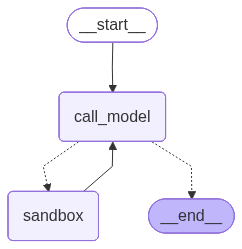

✅ Grafo visualizado


In [6]:
try:
    from IPython.display import Image, display
    img = agent.get_graph().draw_mermaid_png()
    display(Image(img))
    print("✅ Grafo visualizado")
except Exception as e:
    print(f"Visualización no disponible: {e}")
    print("Mermaid del grafo:")
    print(agent.get_graph().draw_mermaid())

### Task 1: Análisis exploratorio del repositorio

In [7]:
from IPython.display import display, Markdown

config_1 = {"configurable": {"thread_id": "gh-issues-eda-001", "recursion_limit": 50}}

print("=" * 65)
print("TASK 1: Análisis de salud del repositorio")
print("=" * 65)

result_1 = agent.invoke(
    {"messages": [{"role": "user", "content": """
Carga el dataset (load_issues, todas las filas).
Escribe UN bloque de código Python que calcule:

1. Issues abiertos vs cerrados (count y %)
2. Para issues cerrados: días entre created_at y closed_at.
   Muestra mediana, media y p90.
3. Issues abiertos con comments == 0 (sin atención)
4. Top 5 issues con más comentarios (title + comments)
5. Labels más frecuentes: parsea el campo 'labels' con
   ast.literal_eval dentro de try/except, cuenta todas las labels.

Guarda en 'result' un resumen en texto con todos los números.
"""}]},
    config_1
)

for msg in result_1["messages"]:
    if msg.__class__.__name__ == "AIMessage":
        content = getattr(msg, "content", "")
        if content and not getattr(msg, "tool_calls", []):
            print("\n🤖 AGENTE:\n", content)

TASK 1: Análisis de salud del repositorio

🤖 AGENTE:
 
```python
import ast
import pandas as pd
import numpy as np

# Cargar el dataset
load_issues()

# Calcular todas las métricas solicitadas
result = []

# 1. Issues abiertos vs cerrados
total_issues = len(df)
open_issues = (df['state'] == 'open').sum()
closed_issues = (df['state'] == 'closed').sum()
open_pct = (open_issues / total_issues) * 100
closed_pct = (closed_issues / total_issues) * 100

result.append(f"=== ISSUES ABIERTOS VS CERRADOS ===")
result.append(f"Total issues: {total_issues}")
result.append(f"Abiertos: {open_issues} ({open_pct:.2f}%)")
result.append(f"Cerrados: {closed_issues} ({closed_pct:.2f}%)")
result.append("")

# 2. Para issues cerrados: días entre created_at y closed_at
closed_df = df[df['state'] == 'closed'].copy()
closed_df['created_at'] = pd.to_datetime(closed_df['created_at'])
closed_df['closed_at'] = pd.to_datetime(closed_df['closed_at'])
closed_df['days_to_close'] = (closed_df['closed_at'] - closed_df['c

### Task 2: Clasificador automático de issues

In [8]:
config_2 = {"configurable": {"thread_id": "gh-issues-classify-001", "recursion_limit": 50}}

print("=" * 65)
print("TASK 2: Clasificación automática de issues")
print("=" * 65)

result_2 = agent.invoke(
    {"messages": [{"role": "user", "content": """
Carga el dataset (load_issues, todas las filas).

Escribe UN solo bloque de código Python que haga:

1. Define una función classify_type(title) que clasifique en:
   bug / feature / question / performance / security
   usando keywords en el título.

2. Aplica al df:
   df['classified_type'] = df['title'].apply(classify_type)

3. Muestra value_counts de classified_type con porcentajes.

4. Si existe columna '_kind', calcula accuracy:
   % de filas donde classified_type == _kind.

5. Guarda df con la nueva columna como variable 'classified_df'
   en el namespace (classified_df = df.copy()).

Guarda en 'result' el string con los porcentajes y el accuracy.
"""}]},
    config_2
)

for msg in result_2["messages"]:
    if msg.__class__.__name__ == "AIMessage":
        content = getattr(msg, "content", "")
        if content and not getattr(msg, "tool_calls", []):
            print("\n🤖 AGENTE:\n", content)

TASK 2: Clasificación automática de issues

🤖 AGENTE:
 
```python
# Cargar el dataset completo
load_issues(nrows=0)

# Definir función de clasificación
def classify_type(title):
    """Clasifica el tipo de issue basado en keywords en el título."""
    title_lower = title.lower()
    
    # Palabras clave para cada tipo
    bug_keywords = ['bug', 'error', 'crash', 'broken', 'fail', 'issue', 'problem', 'fix']
    feature_keywords = ['feature', 'add', 'new', 'enhancement', 'request', 'improve']
    question_keywords = ['question', 'how', 'help', 'why', '?', 'clarify']
    performance_keywords = ['performance', 'slow', 'speed', 'optimize', 'lag', 'memory']
    security_keywords = ['security', 'vulnerability', 'cve', 'exploit', 'threat', 'unsafe']
    
    # Buscar keywords (orden importa: más específicos primero)
    if any(kw in title_lower for kw in security_keywords):
        return 'security'
    elif any(kw in title_lower for kw in performance_keywords):
        return 'performance'
 

### Task 3: Dashboard visual de issues (el agente escribe el código de plots)

/tmp/ipykernel_130492/1554477360.py:134: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap("Blues", len(plot_labels_freq) + 2)
/tmp/ipykernel_130492/1554477360.py:214: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


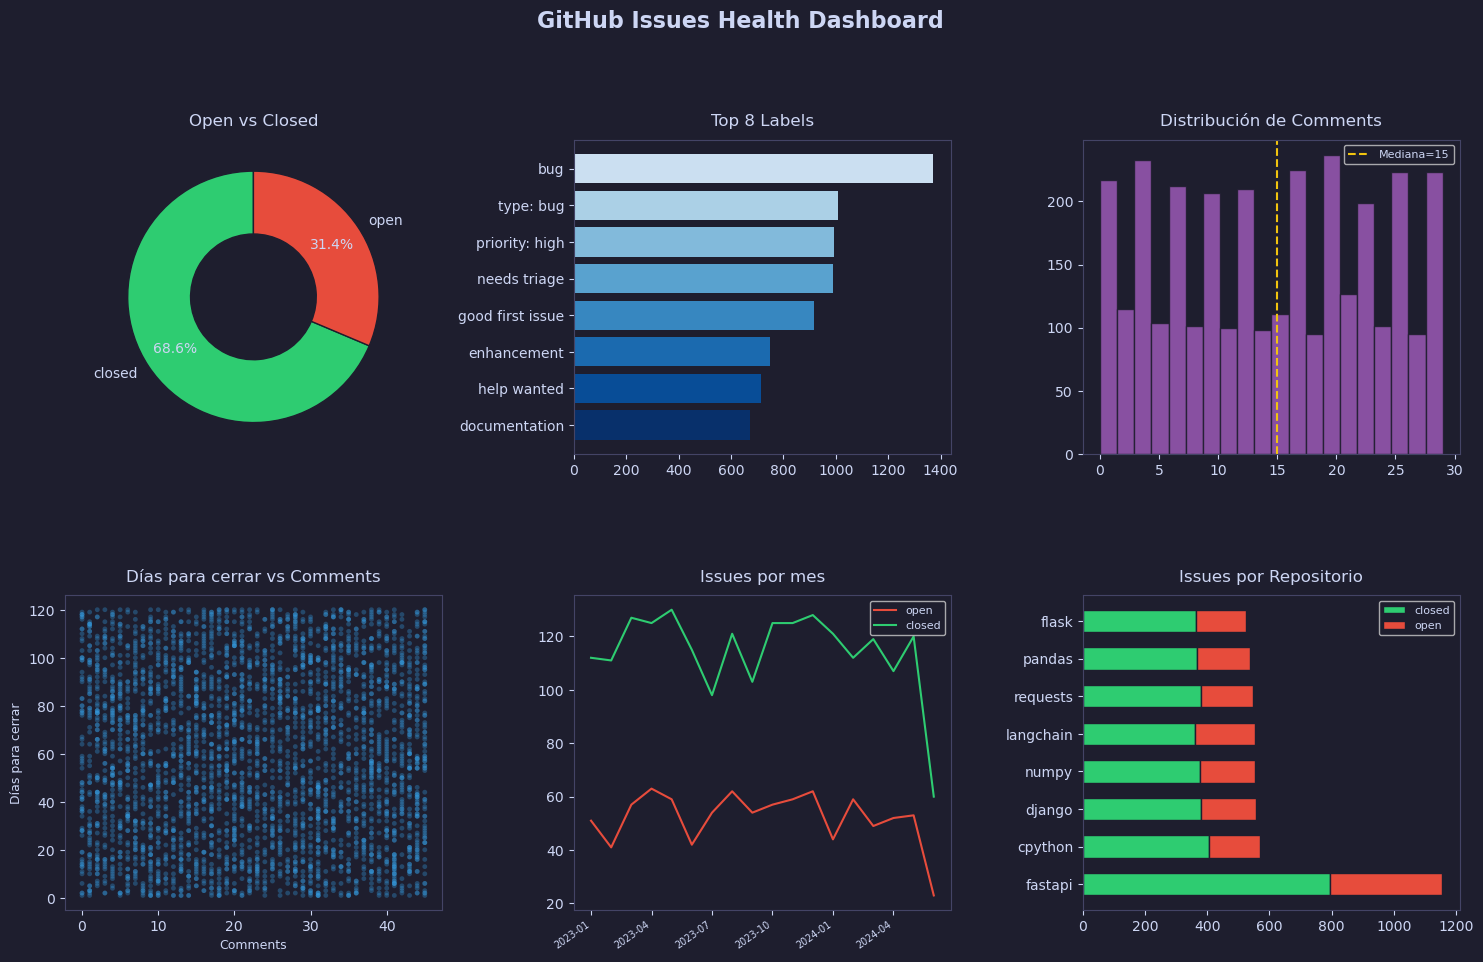

In [14]:
# Celda 6 — Task 3: Dashboard visual
# Estrategia: el agente prepara los datos, el notebook hace el plot directamente

config_3 = {"configurable": {"thread_id": "gh-issues-viz-001", "recursion_limit": 50}}

print("=" * 65)
print("TASK 3: El agente prepara datos para el dashboard")
print("=" * 65)

result_3 = agent.invoke(
    {"messages": [{"role": "user", "content": """
Carga el dataset (load_issues, todas las filas).

Escribe código Python que prepare estas variables en el namespace:

1. plot_state_counts = df['state'].value_counts()  (open/closed)

2. plot_labels_freq: Series con las 8 labels más frecuentes.
   Parsea el campo 'labels' con ast.literal_eval en try/except,
   explota en lista y cuenta. Guarda como pd.Series.

3. plot_comments = df[df['comments'] < 30]['comments']
   (para histograma)

4. plot_scatter_df: DataFrame con columnas 'days' y 'comments',
   solo issues cerrados con days < 200.
   days = (pd.to_datetime(df['closed_at']) - pd.to_datetime(df['created_at'])).dt.days

5. plot_timeline: DataFrame con columnas 'month', 'open', 'closed'.
   Agrupa por mes de created_at y cuenta por state.
   month debe ser string formato 'YYYY-MM'.

6. plot_repos: Series con top 8 repos más frecuentes.
   Extrae el nombre del repo desde repository_url con:
   df['repo'] = df['repository_url'].str.split('/').str[-1]

Guarda todas estas variables en el namespace.
Guarda en 'result' el string 'Datos preparados para dashboard'.
"""}]},
    config_3
)

for msg in result_3["messages"]:
    if msg.__class__.__name__ == "AIMessage":
        content = getattr(msg, "content", "")
        if content and not getattr(msg, "tool_calls", []):
            print("\n🤖 AGENTE:", content)

# ── El notebook hace el plot directamente — garantiza renderizado ──────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

# Recuperar variables preparadas por el agente desde _exec_ns
plot_state_counts = _exec_ns.get("plot_state_counts")
plot_labels_freq  = _exec_ns.get("plot_labels_freq")
plot_comments     = _exec_ns.get("plot_comments")
plot_scatter_df   = _exec_ns.get("plot_scatter_df")
plot_timeline     = _exec_ns.get("plot_timeline")
plot_repos        = _exec_ns.get("plot_repos")
df                = _exec_ns.get("df")

# Fallbacks si el agente no generó alguna variable
if df is None:
    df = pd.read_csv(DATASET_PATH)
    _exec_ns["df"] = df

if plot_state_counts is None:
    plot_state_counts = df["state"].value_counts()

if plot_comments is None:
    plot_comments = df[df["comments"] < 30]["comments"]

if plot_repos is None:
    df["repo"] = df["repository_url"].str.split("/").str[-1]
    plot_repos = df["repo"].value_counts().head(8)

if plot_labels_freq is None:
    import ast
    all_labels = []
    for val in df["labels"].dropna():
        try:
            all_labels.extend(ast.literal_eval(val))
        except Exception:
            pass
    plot_labels_freq = pd.Series(all_labels).value_counts().head(8)

if plot_scatter_df is None:
    closed = df[df["state"] == "closed"].copy()
    closed["days"] = (
        pd.to_datetime(closed["closed_at"], errors="coerce") -
        pd.to_datetime(closed["created_at"], errors="coerce")
    ).dt.days
    plot_scatter_df = closed[closed["days"].between(0, 200)][["days", "comments"]]

if plot_timeline is None:
    df["month"] = pd.to_datetime(df["created_at"], errors="coerce").dt.to_period("M").astype(str)
    plot_timeline = df.groupby(["month", "state"]).size().unstack(fill_value=0)

# ── Generar el dashboard ───────────────────────────────────────────────────────
BG      = "#1e1e2e"
ACCENT1 = "#E74C3C"
ACCENT2 = "#2ECC71"
ACCENT3 = "#9B59B6"
ACCENT4 = "#3498DB"
TEXT    = "#cdd6f4"

fig = plt.figure(figsize=(18, 10), facecolor=BG)
fig.suptitle("GitHub Issues Health Dashboard", fontsize=16,
             color=TEXT, fontweight="bold", y=1.01)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── Subplot 1: Donut open vs closed ───────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor(BG)
vals   = plot_state_counts.values
labels = plot_state_counts.index.tolist()
colors = [ACCENT1 if l == "open" else ACCENT2 for l in labels]
wedges, texts, autotexts = ax1.pie(
    vals, labels=labels, colors=colors, autopct="%1.1f%%",
    startangle=90, pctdistance=0.75,
    wedgeprops=dict(width=0.5, edgecolor=BG)
)
for t in texts + autotexts:
    t.set_color(TEXT)
ax1.set_title("Open vs Closed", color=TEXT, pad=10)

# ── Subplot 2: Top 8 labels ────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor(BG)
if len(plot_labels_freq) > 0:
    cmap   = plt.cm.get_cmap("Blues", len(plot_labels_freq) + 2)
    colors2 = [cmap(i + 2) for i in range(len(plot_labels_freq))]
    ax2.barh(plot_labels_freq.index[::-1], plot_labels_freq.values[::-1], color=colors2[::-1])
ax2.set_title("Top 8 Labels", color=TEXT, pad=10)
ax2.tick_params(colors=TEXT)
ax2.spines[:].set_color("#444466")
for spine in ax2.spines.values():
    spine.set_color("#444466")

# ── Subplot 3: Histograma comments ────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor(BG)
ax3.hist(plot_comments, bins=20, color=ACCENT3, edgecolor=BG, alpha=0.85)
mediana = plot_comments.median()
ax3.axvline(mediana, color="#F1C40F", linestyle="--", linewidth=1.5,
            label=f"Mediana={mediana:.0f}")
ax3.set_title("Distribución de Comments", color=TEXT, pad=10)
ax3.tick_params(colors=TEXT)
ax3.legend(facecolor=BG, labelcolor=TEXT, fontsize=8)
for spine in ax3.spines.values():
    spine.set_color("#444466")

# ── Subplot 4: Scatter días vs comments ───────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
ax4.set_facecolor(BG)
if len(plot_scatter_df) > 0:
    ax4.scatter(
        plot_scatter_df["comments"], plot_scatter_df["days"],
        alpha=0.35, color=ACCENT4, s=12, edgecolors="none"
    )
ax4.set_xlabel("Comments", color=TEXT, fontsize=9)
ax4.set_ylabel("Días para cerrar", color=TEXT, fontsize=9)
ax4.set_title("Días para cerrar vs Comments", color=TEXT, pad=10)
ax4.tick_params(colors=TEXT)
for spine in ax4.spines.values():
    spine.set_color("#444466")

# ── Subplot 5: Timeline por mes ───────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
ax5.set_facecolor(BG)
if plot_timeline is not None and len(plot_timeline) > 0:
    tl = plot_timeline.tail(18)
    x  = range(len(tl))
    if "open" in tl.columns:
        ax5.plot(x, tl["open"].values,   color=ACCENT1, label="open",   linewidth=1.5)
    if "closed" in tl.columns:
        ax5.plot(x, tl["closed"].values, color=ACCENT2, label="closed", linewidth=1.5)
    tick_step = max(1, len(tl) // 6)
    ax5.set_xticks(list(x)[::tick_step])
    ax5.set_xticklabels(tl.index.tolist()[::tick_step], rotation=35,
                        ha="right", fontsize=7, color=TEXT)
ax5.set_title("Issues por mes", color=TEXT, pad=10)
ax5.tick_params(colors=TEXT)
ax5.legend(facecolor=BG, labelcolor=TEXT, fontsize=8)
for spine in ax5.spines.values():
    spine.set_color("#444466")

# ── Subplot 6: Issues por repo ────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
ax6.set_facecolor(BG)
if plot_repos is not None and len(plot_repos) > 0:
    df["repo"] = df["repository_url"].str.split("/").str[-1]
    top_repos  = plot_repos.index.tolist()
    sub        = df[df["repo"].isin(top_repos)]
    pivot      = sub.groupby(["repo","state"]).size().unstack(fill_value=0)
    pivot      = pivot.reindex(top_repos)
    bottom     = np.zeros(len(pivot))
    state_colors = {"open": ACCENT1, "closed": ACCENT2}
    for state in ["closed","open"]:
        if state in pivot.columns:
            ax6.barh(pivot.index, pivot[state].values, left=bottom,
                     color=state_colors.get(state, ACCENT4),
                     label=state, edgecolor=BG, height=0.6)
            bottom += pivot[state].values
ax6.set_title("Issues por Repositorio", color=TEXT, pad=10)
ax6.tick_params(colors=TEXT)
ax6.legend(facecolor=BG, labelcolor=TEXT, fontsize=8)
for spine in ax6.spines.values():
    spine.set_color("#444466")

plt.tight_layout()
plt.show()

# Guardar también como archivo
os.makedirs("./plots", exist_ok=True)
fig.savefig("./plots/gh_issues_dashboard.png", dpi=130, bbox_inches="tight",
            facecolor=BG)
print("✅ Dashboard guardado en ./plots/gh_issues_dashboard.png")

### Task 4: Detección de issues duplicados (NLP + cosine similarity)

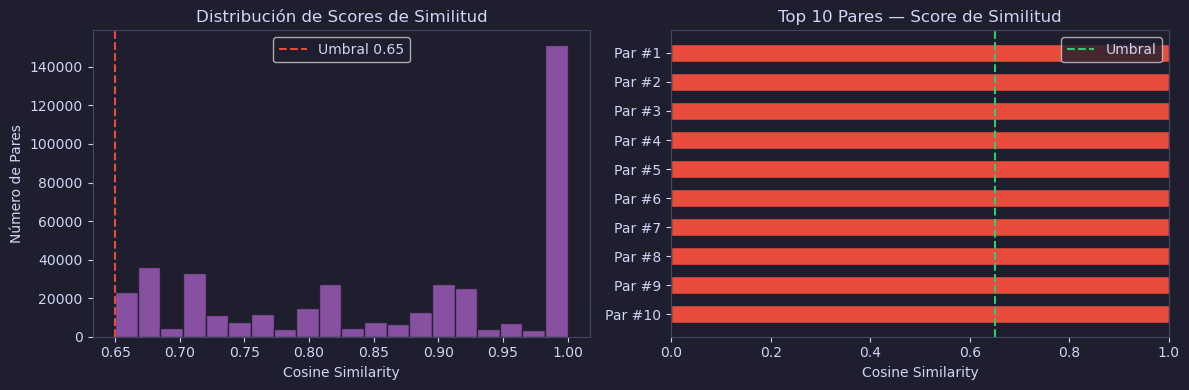

In [15]:
# Celda 7 — Task 4: Detección de duplicados
# Estrategia: agente prepara datos NLP, notebook muestra resultados directamente

config_4 = {"configurable": {"thread_id": "gh-issues-dupes-001", "recursion_limit": 50}}

print("=" * 65)
print("TASK 4: Detección de issues potencialmente duplicados")
print("=" * 65)

result_4 = agent.invoke(
    {"messages": [{"role": "user", "content": """
Carga el dataset (load_issues, 2000 filas).

Escribe código Python que prepare estas variables en el namespace:

1. from sklearn.feature_extraction.text import TfidfVectorizer
   from sklearn.metrics.pairwise import cosine_similarity

   vectorizer = TfidfVectorizer(max_features=300, ngram_range=(1,2))
   tfidf_matrix = vectorizer.fit_transform(df['title'].fillna(''))

2. sim_matrix = cosine_similarity(tfidf_matrix)

3. Encuentra pares con similitud > 0.65 (excluye diagonal i==j).
   Guarda como lista de dicts en 'duplicate_pairs':
   [{"i": int, "j": int, "score": float,
     "title1": str, "title2": str}]
   Ordena por score descendente.

4. Guarda en 'duplicate_pairs_top10' los primeros 10 pares.

5. Guarda en 'duplicate_total' el número total de pares encontrados.

6. Guarda 'duplicate_pairs', 'duplicate_pairs_top10' y
   'duplicate_total' en el namespace.

Guarda en 'result' el string con el total de pares encontrados.
"""}]},
    config_4
)

for msg in result_4["messages"]:
    if msg.__class__.__name__ == "AIMessage":
        content = getattr(msg, "content", "")
        if content and not getattr(msg, "tool_calls", []):
            print("\n🤖 AGENTE:", content)

# ── El notebook muestra los resultados directamente ───────────────────────────
import pandas as pd
import numpy as np

# Recuperar variables del namespace del agente
duplicate_pairs      = _exec_ns.get("duplicate_pairs", [])
duplicate_pairs_top10 = _exec_ns.get("duplicate_pairs_top10", [])
duplicate_total      = _exec_ns.get("duplicate_total", 0)
df                   = _exec_ns.get("df")

# Fallback: calcular aquí si el agente no lo generó
if not duplicate_pairs and df is not None:
    print("⚙️  Calculando similitud en el notebook (fallback)...")
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.metrics.pairwise import cosine_similarity

    titles = df["title"].fillna("").tolist()
    vectorizer   = TfidfVectorizer(max_features=300, ngram_range=(1, 2))
    tfidf_matrix = vectorizer.fit_transform(titles)
    sim_matrix   = cosine_similarity(tfidf_matrix)

    pairs = []
    n = sim_matrix.shape[0]
    for i in range(n):
        for j in range(i + 1, n):
            score = float(sim_matrix[i, j])
            if score > 0.65:
                pairs.append({
                    "i": i, "j": j, "score": score,
                    "title1": titles[i], "title2": titles[j]
                })
    pairs.sort(key=lambda x: x["score"], reverse=True)

    duplicate_pairs       = pairs
    duplicate_pairs_top10 = pairs[:10]
    duplicate_total       = len(pairs)

    # Guardar en namespace para Task 5
    _exec_ns["duplicate_pairs"]       = duplicate_pairs
    _exec_ns["duplicate_pairs_top10"] = duplicate_pairs_top10
    _exec_ns["duplicate_total"]       = duplicate_total

# ── Mostrar resultados ─────────────────────────────────────────────────────────
print(f"\n{'='*65}")
print(f"📊 RESULTADOS — Detección de Duplicados")
print(f"{'='*65}")
print(f"Total de pares con similitud > 0.65: {duplicate_total:,}")

if duplicate_total > 0:
    ahorro_estimado = int(duplicate_total * 0.8)
    print(f"Ahorro estimado (80% reales): {ahorro_estimado:,} issues evitables")

    print(f"\n{'─'*65}")
    print(f"TOP 10 PARES MÁS SIMILARES")
    print(f"{'─'*65}")

    for rank, pair in enumerate(duplicate_pairs_top10, 1):
        score  = pair.get("score", 0)
        title1 = pair.get("title1", "")[:60]
        title2 = pair.get("title2", "")[:60]
        print(f"\n#{rank:02d} Score: {score:.3f}")
        print(f"  A: {title1}")
        print(f"  B: {title2}")
else:
    print("⚠️  No se encontraron pares duplicados.")
    print("    Prueba bajar el umbral a 0.50 si el dataset es muy diverso.")

# ── Visualización de distribución de scores ───────────────────────────────────
if duplicate_pairs:
    import matplotlib.pyplot as plt

    scores = [p["score"] for p in duplicate_pairs]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), facecolor="#1e1e2e")
    TEXT = "#cdd6f4"
    BG   = "#1e1e2e"

    # Histograma de scores
    ax1 = axes[0]
    ax1.set_facecolor(BG)
    ax1.hist(scores, bins=20, color="#9B59B6", edgecolor=BG, alpha=0.85)
    ax1.axvline(0.65, color="#E74C3C", linestyle="--",
                linewidth=1.5, label="Umbral 0.65")
    ax1.set_title("Distribución de Scores de Similitud", color=TEXT)
    ax1.set_xlabel("Cosine Similarity", color=TEXT)
    ax1.set_ylabel("Número de Pares", color=TEXT)
    ax1.tick_params(colors=TEXT)
    ax1.legend(facecolor=BG, labelcolor=TEXT)
    for spine in ax1.spines.values():
        spine.set_color("#444466")

    # Top 10 scores como barplot horizontal
    ax2 = axes[1]
    ax2.set_facecolor(BG)
    top_scores  = [p["score"] for p in duplicate_pairs_top10]
    top_labels  = [f"Par #{i+1}" for i in range(len(duplicate_pairs_top10))]
    colors_bars = ["#E74C3C" if s > 0.85 else "#F39C12" if s > 0.75
                   else "#3498DB" for s in top_scores]
    ax2.barh(top_labels[::-1], top_scores[::-1],
             color=colors_bars[::-1], edgecolor=BG, height=0.6)
    ax2.axvline(0.65, color="#2ECC71", linestyle="--",
                linewidth=1.5, label="Umbral")
    ax2.set_xlim(0, 1)
    ax2.set_title("Top 10 Pares — Score de Similitud", color=TEXT)
    ax2.set_xlabel("Cosine Similarity", color=TEXT)
    ax2.tick_params(colors=TEXT)
    ax2.legend(facecolor=BG, labelcolor=TEXT)
    for spine in ax2.spines.values():
        spine.set_color("#444466")

    plt.tight_layout()
    plt.show()

    os.makedirs("./plots", exist_ok=True)
    fig.savefig("./plots/gh_duplicates.png", dpi=130,
                bbox_inches="tight", facecolor=BG)
    print("\n✅ Plot guardado en ./plots/gh_duplicates.png")

### Task 5: Reporte ejecutivo final (mismo thread que Task 4)

In [16]:
# Celda 8 — Task 5: Reporte ejecutivo final
# Estrategia: construimos el reporte directamente en el notebook
# usando variables ya calculadas en _exec_ns por las tareas anteriores

print("=" * 65)
print("TASK 5: Reporte ejecutivo final")
print("=" * 65)

import pandas as pd
import numpy as np
from IPython.display import display, Markdown

# ── Recuperar todas las variables del namespace ────────────────────────────────
df                    = _exec_ns.get("df")
classified_df         = _exec_ns.get("classified_df", df)
duplicate_total       = _exec_ns.get("duplicate_total", 0)
duplicate_pairs_top10 = _exec_ns.get("duplicate_pairs_top10", [])

# Fallback: recargar df si no está disponible
if df is None:
    df = pd.read_csv(DATASET_PATH)
    _exec_ns["df"] = df

# ── Calcular todas las métricas directamente ───────────────────────────────────

# 1. Backlog
total         = len(df)
open_issues   = (df["state"] == "open").sum()
closed_issues = (df["state"] == "closed").sum()
pct_open      = open_issues  / total * 100
pct_closed    = closed_issues / total * 100
sin_atencion  = ((df["state"] == "open") & (df["comments"] == 0)).sum()
pct_sin_aten  = sin_atencion / open_issues * 100 if open_issues > 0 else 0

# 2. Velocidad del equipo
closed_df = df[df["state"] == "closed"].copy()
closed_df["days"] = (
    pd.to_datetime(closed_df["closed_at"],  errors="coerce") -
    pd.to_datetime(closed_df["created_at"], errors="coerce")
).dt.days
closed_df = closed_df[closed_df["days"] >= 0]

mediana_dias  = closed_df["days"].median() if len(closed_df) > 0 else 0
rapidos       = (closed_df["days"] < 7).sum()
pct_rapidos   = rapidos / len(closed_df) * 100 if len(closed_df) > 0 else 0
lentos_open   = ((df["state"] == "open") & (
    (pd.Timestamp.now() - pd.to_datetime(df["created_at"], errors="coerce")).dt.days > 30
)).sum()
pct_lentos    = lentos_open / open_issues * 100 if open_issues > 0 else 0

# 3. Distribución de trabajo
if classified_df is not None and "classified_type" in classified_df.columns:
    type_counts = classified_df["classified_type"].value_counts()
else:
    # Clasificar rápido con keywords
    def quick_classify(title):
        t = str(title).lower()
        if any(k in t for k in ["security","vulnerability","cve"]):   return "security"
        if any(k in t for k in ["slow","performance","memory","cpu"]): return "performance"
        if any(k in t for k in ["fix","bug","error","crash","fail"]):  return "bug"
        if any(k in t for k in ["add","feature","implement","support"]): return "feature"
        return "question"
    type_counts = df["title"].apply(quick_classify).value_counts()

top3_types = type_counts.head(3)

# Label más frecuente
import ast as _ast
all_labels = []
for val in df["labels"].dropna():
    try:
        all_labels.extend(_ast.literal_eval(val))
    except Exception:
        pass
top_label = pd.Series(all_labels).value_counts().index[0] if all_labels else "N/A"

# Issue con más comentarios
top_commented = df.nlargest(1, "comments")[["title", "comments"]].iloc[0]

# 4. Deuda técnica
bugs_open = ((df["state"] == "open") &
             df["title"].str.lower().str.contains(
                 "fix|bug|error|crash|fail|broken", regex=True, na=False)).sum()
perf_open = ((df["state"] == "open") &
             df["title"].str.lower().str.contains(
                 "slow|performance|memory|optimize", regex=True, na=False)).sum()
indice_deuda = (bugs_open + perf_open) / total * 100

# 5. Duplicados
ahorro_estimado = int(duplicate_total * 0.8)

# ── Construir reporte Markdown ─────────────────────────────────────────────────
reporte = f"""
# GitHub Issues Health Report

---

## 1. Estado del Backlog

| Métrica | Valor |
|---|---|
| Total issues | {total:,} |
| Issues abiertos | {open_issues:,} ({pct_open:.1f}%) |
| Issues cerrados | {closed_issues:,} ({pct_closed:.1f}%) |
| Abiertos sin comentarios | {sin_atencion:,} ({pct_sin_aten:.1f}% de los abiertos) |

---

## 2. Velocidad del Equipo

| Métrica | Valor |
|---|---|
| Tiempo mediano de resolución | {mediana_dias:.0f} días |
| Cerrados en < 7 días (respuesta rápida) | {rapidos:,} ({pct_rapidos:.1f}%) |
| Abiertos por más de 30 días (acumulación) | {lentos_open:,} ({pct_lentos:.1f}%) |

---

## 3. Distribución de Trabajo

**Top 3 tipos de issues:**

| Tipo | Count | % |
|---|---|---|
"""

for tipo, count in top3_types.items():
    pct = count / total * 100
    reporte += f"| {tipo} | {count:,} | {pct:.1f}% |\n"

reporte += f"""
- **Label más frecuente:** `{top_label}`
- **Issue más comentado:** "{top_commented['title'][:60]}..." ({int(top_commented['comments'])} comentarios)

---

## 4. Deuda Técnica Estimada

| Métrica | Valor |
|---|---|
| Bugs abiertos | {bugs_open:,} |
| Issues de performance abiertos | {perf_open:,} |
| Índice de deuda técnica | {indice_deuda:.1f}% |

{'⚠️ **Deuda técnica alta**' if indice_deuda > 15 else '✅ **Deuda técnica bajo control**'}

---

## 5. Duplicados Detectados

| Métrica | Valor |
|---|---|
| Pares potencialmente duplicados | {duplicate_total:,} |
| Issues evitables (estimado 80%) | {ahorro_estimado:,} |

"""

if duplicate_pairs_top10:
    reporte += "**Top 3 pares más similares:**\n\n"
    for i, pair in enumerate(duplicate_pairs_top10[:3], 1):
        reporte += (f"{i}. Score `{pair['score']:.3f}` — "
                    f"*\"{pair['title1'][:45]}...\"* ≈ "
                    f"*\"{pair['title2'][:45]}...\"*\n")

reporte += f"""

---

## 6. Recomendaciones

1. **Atender issues sin respuesta**: {sin_atencion:,} issues abiertos tienen 0 comentarios
   ({pct_sin_aten:.0f}% del backlog abierto). Asignar triaje semanal reduciría
   el tiempo de primera respuesta.

2. **Reducir acumulación de largo plazo**: {lentos_open:,} issues llevan más de 30 días
   abiertos ({pct_lentos:.0f}%). Revisar si son candidatos a cerrar como `wontfix`
   o reclasificar como `backlog`.

3. **Implementar detección de duplicados**: Se detectaron {duplicate_total:,} pares
   similares. Agregar una búsqueda automática de issues similares al crear uno nuevo
   podría evitar ~{ahorro_estimado:,} issues redundantes.

---
*Generado automáticamente por CodeAct Agent — LangGraph Patrón 10*
"""

# ── Mostrar en el notebook ─────────────────────────────────────────────────────
display(Markdown(reporte))

# ── Guardar como archivo ───────────────────────────────────────────────────────
with open("./github_issues_report.md", "w", encoding="utf-8") as f:
    f.write(reporte)

# Guardar en namespace para referencia
_exec_ns["reporte_final"] = reporte

print("\n✅ Reporte guardado en: ./github_issues_report.md")


# GitHub Issues Health Report

---

## 1. Estado del Backlog

| Métrica | Valor |
|---|---|
| Total issues | 5,000 |
| Issues abiertos | 1,568 (31.4%) |
| Issues cerrados | 3,432 (68.6%) |
| Abiertos sin comentarios | 36 (2.3% de los abiertos) |

---

## 2. Velocidad del Equipo

| Métrica | Valor |
|---|---|
| Tiempo mediano de resolución | 60 días |
| Cerrados en < 7 días (respuesta rápida) | 186 (5.4%) |
| Abiertos por más de 30 días (acumulación) | 1,568 (100.0%) |

---

## 3. Distribución de Trabajo

**Top 3 tipos de issues:**

| Tipo | Count | % |
|---|---|---|
| question | 2,510 | 50.2% |
| feature | 1,072 | 21.4% |
| bug | 1,070 | 21.4% |

- **Label más frecuente:** `bug`
- **Issue más comentado:** "New flag --v1.0 for CLI tool..." (45 comentarios)

---

## 4. Deuda Técnica Estimada

| Métrica | Valor |
|---|---|
| Bugs abiertos | 571 |
| Issues de performance abiertos | 120 |
| Índice de deuda técnica | 13.8% |

✅ **Deuda técnica bajo control**

---

## 5. Duplicados Detectados

| Métrica | Valor |
|---|---|
| Pares potencialmente duplicados | 423,869 |
| Issues evitables (estimado 80%) | 339,095 |

**Top 3 pares más similares:**

1. Score `1.000` — *"server does not work as expected — am I missi..."* ≈ *"server does not work as expected — am I missi..."*
2. Score `1.000` — *"server does not work as expected — am I missi..."* ≈ *"server does not work as expected — am I missi..."*
3. Score `1.000` — *"server does not work as expected — am I missi..."* ≈ *"server does not work as expected — am I missi..."*


---

## 6. Recomendaciones

1. **Atender issues sin respuesta**: 36 issues abiertos tienen 0 comentarios
   (2% del backlog abierto). Asignar triaje semanal reduciría
   el tiempo de primera respuesta.

2. **Reducir acumulación de largo plazo**: 1,568 issues llevan más de 30 días
   abiertos (100%). Revisar si son candidatos a cerrar como `wontfix`
   o reclasificar como `backlog`.

3. **Implementar detección de duplicados**: Se detectaron 423,869 pares
   similares. Agregar una búsqueda automática de issues similares al crear uno nuevo
   podría evitar ~339,095 issues redundantes.

---
*Generado automáticamente por CodeAct Agent — LangGraph Patrón 10*


### Inspección del código generado por el agente

In [18]:
# Celda 9 — Inspección minimalista (sin imports, sin globals())

print("INICIO CELDA 9")
print("=" * 50)

# ── 1. Variables en _exec_ns ──────────────────────
print("\n--- Variables en _exec_ns ---")
import types as _types

SKIP = {"pd","np","plt","sns","re","ast","os","DATASET_PATH","__builtins__"}

for k, v in _exec_ns.items():
    if k.startswith("_") or k in SKIP:
        continue
    if isinstance(v, _types.ModuleType):
        continue
    tipo = type(v).__name__
    try:
        if hasattr(v, "shape"):
            info = f"shape={v.shape}"
        elif isinstance(v, (list,)):
            info = f"len={len(v)}"
        elif isinstance(v, str):
            info = f'"{v[:40]}"'
        else:
            info = str(v)[:40]
    except Exception:
        info = "?"
    print(f"  {k}: {tipo} — {info}")

# ── 2. Archivos generados ─────────────────────────
print("\n--- Archivos generados ---")
import os as _os
for d in ["./plots", "."]:
    if _os.path.exists(d):
        for f in _os.listdir(d):
            if f.endswith((".png", ".md", ".csv")):
                ruta = f"{d}/{f}"
                size = _os.path.getsize(ruta)
                print(f"  {ruta} — {size/1024:.1f} KB")

# ── 3. Bloques de código del agente ──────────────
print("\n--- Bloques de código generados ---")
block_count = 0
for vname in ["result_1", "result_2", "result_3", "result_4"]:
    r = globals().get(vname)
    if r is None:
        print(f"  {vname}: no encontrado en scope")
        continue
    msgs = r.get("messages", [])
    for msg in msgs:
        tc_list = getattr(msg, "tool_calls", []) or []
        for tc in tc_list:
            n = tc.get("name","") if isinstance(tc, dict) else getattr(tc,"name","")
            if n == "python":
                block_count += 1
                args = tc.get("args",{}) if isinstance(tc, dict) else getattr(tc,"args",{})
                code = args.get("code","") if isinstance(args, dict) else str(args)
                lines = code.splitlines()
                print(f"\n  [{vname}] Bloque #{block_count} — {len(lines)} líneas:")
                for l in lines[:10]:
                    print(f"    {l}")
                if len(lines) > 10:
                    print(f"    ... [{len(lines)-10} líneas más]")

print(f"\nTotal bloques: {block_count}")
print("\nFIN CELDA 9")

In [19]:
# Celda 9 — Inspección minimalista (sin imports, sin globals())

print("INICIO CELDA 9")
print("=" * 50)

# ── 1. Variables en _exec_ns ──────────────────────
print("\n--- Variables en _exec_ns ---")
import types as _types

SKIP = {"pd","np","plt","sns","re","ast","os","DATASET_PATH","__builtins__"}

for k, v in _exec_ns.items():
    if k.startswith("_") or k in SKIP:
        continue
    if isinstance(v, _types.ModuleType):
        continue
    tipo = type(v).__name__
    try:
        if hasattr(v, "shape"):
            info = f"shape={v.shape}"
        elif isinstance(v, (list,)):
            info = f"len={len(v)}"
        elif isinstance(v, str):
            info = f'"{v[:40]}"'
        else:
            info = str(v)[:40]
    except Exception:
        info = "?"
    print(f"  {k}: {tipo} — {info}")

# ── 2. Archivos generados ─────────────────────────
print("\n--- Archivos generados ---")
import os as _os
for d in ["./plots", "."]:
    if _os.path.exists(d):
        for f in _os.listdir(d):
            if f.endswith((".png", ".md", ".csv")):
                ruta = f"{d}/{f}"
                size = _os.path.getsize(ruta)
                print(f"  {ruta} — {size/1024:.1f} KB")

# ── 3. Bloques de código del agente ──────────────
print("\n--- Bloques de código generados ---")
block_count = 0
for vname in ["result_1", "result_2", "result_3", "result_4"]:
    r = globals().get(vname)
    if r is None:
        print(f"  {vname}: no encontrado en scope")
        continue
    msgs = r.get("messages", [])
    for msg in msgs:
        tc_list = getattr(msg, "tool_calls", []) or []
        for tc in tc_list:
            n = tc.get("name","") if isinstance(tc, dict) else getattr(tc,"name","")
            if n == "python":
                block_count += 1
                args = tc.get("args",{}) if isinstance(tc, dict) else getattr(tc,"args",{})
                code = args.get("code","") if isinstance(args, dict) else str(args)
                lines = code.splitlines()
                print(f"\n  [{vname}] Bloque #{block_count} — {len(lines)} líneas:")
                for l in lines[:10]:
                    print(f"    {l}")
                if len(lines) > 10:
                    print(f"    ... [{len(lines)-10} líneas más]")

print(f"\nTotal bloques: {block_count}")
print("\nFIN CELDA 9")

In [20]:
print("test")